In [2]:
from statsmodels.tsa.base import prediction
from torch_geometric.io import sdf

'''
我的第一个决策树项目是一个阿里云竞赛项目，社交链接预测，使用LightGBM+GNN进行一个组合，强化了AUC，但是MRR在熟人圈子里处于0.74，算是一个能用的状态，但是我不满意。

LightGBM是一个轻量级决策树，类似的GBM是常量级。
XGBoost更强，二阶泰勒展开让分裂更精准，但代价是空间复杂度O(n*log n)，这个模型需要更大内存来进行计算，效果也更显著，所以竞赛上很多人用他。

如果我想做一个AB实验，验证XGBoost能否提高数据表现，然后走云算力平台，快速验证其实很现实。

但是从业务场景上来说，链接预测的排序需求在MRR大于0.5的时候就已经完成了，因为这意味着基本上预测结果都是稳居第一或者第二的位置，这样的预测结果在熟人社交推荐领域其实已经非常可观，因为我们成功将适合链接的朋友推荐给了用户，并且这是可见的形式（第一位或者第二位，这两个在视觉上来说几乎没有先后）。
'''

KeyboardInterrupt: 

In [ ]:
'''
一看到决策树的结构，我就想到P社游戏钢铁雄心4，里面的国策树，同样是树状结构，同样是根据我们达到的数据来允许我们选择对应决策，同样是由上到下。

只不过我们把决策树用来识别和判断，而钢铁雄心4的国策树是一个判断完之后，允许玩家可以选择对应国策的机制。

另外一个方面，国策树涉及到的数据量有限，是封闭的不在线数据，权重都是手敲的，设定都是人设计的，并不智能。

如果我们能通过量化历史，把历史中社会演变的各方面数据建立数据库，并投入到一个决策树里面进行训练，然后通过算力模拟，这实际上就是一个社会历史、动力学的模型。

但量化历史是很难的，如果愿意的话，我们可以借助最近很流行的多模态技术，通过LLM、NLP语义识别，通过大语言模型的世界知识，来进行语义量化，或者周期内某关键词触发频率，进行时代关键词量化，并建立关键词数据库，投入模型训练，这种技术是可行的。
'''

In [3]:
'''
先拉一个鸢尾花数据集，这个数据集里面有150行数据，我们之前写过鸢尾花的案例，列名是叶子形状类型，species是鸢尾花类型，id是索引。
'''

import numpy as np
from pandas import plotting

import pandas as pd
iris = pd.read_csv('D:/MLearning/data/iris.csv',index_col=0)
print(iris)

     sepal_length  sepal_width  petal_length  petal_width         species
id                                                                       
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


In [4]:
'''
现在划分特征集和标签集
"特征"就是我们用来判断鸢尾花类型的叶片形状。
"标签"就是species

说起标签，大家应该在身边都听说过给AI做"打标签"的岗位，就是人工识别一个东西的标签，并给它打上标签，送给机器去学习。
然后机器根据"特征"和"标签"的关联性强度，来获得一组特征最匹配的"标签"，这就做到了所谓的物品识别。

但工业界还有个反向问题：人也会打错。标注员的疲劳、歧义样本、标注标准不统一，都会导致标签噪声。
所以实际项目中，数据清洗和标注质量管控往往比选模型更重要——垃圾标签喂进去，再强的模型也是垃圾预测。

我的社交连接预测项目里有一个is_friend数据泄漏问题，本质上也是一种"标签定义不干净"——标签和特征混在一起了。

推广到CNN神经网络（图像、音频识别）、YOLO动态识别模型，实际上做的是同样的事情，只不过数据结构变了：

平表ML（iris）：   每个样本是一行 → [样本数, 特征数]
                   特征 = 人工定义的列名（"花瓣长度"）
                   模型只学"特征→标签"的映射

图像ML（CNN）：    每个样本本身是一个3D张量 → [样本数, 高, 宽, 通道]
                   特征 = 像素的空间位置关系，不再由人定义
                   模型既要自己从像素里提取特征，又要学映射

视频ML（YOLO）：   再多一个时间维度 → [样本数, 帧, 高, 宽, 通道]
                   五维张量，模型要同时理解空间和时间
'''

# 一个数据清洗工作
iris_features = iris.iloc[:,0:4]
iris_target = iris.iloc[:,4]
print(iris_features)
print(iris_target)


     sepal_length  sepal_width  petal_length  petal_width
id                                                       
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
id
0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica

In [5]:
'''
编码标签集

因为标签集基本上都是文字数据，计算机没法看懂，所以我们需要把标签标记为数字。
比如在CNN水果识别的Kaggle项目中，
西瓜 =》 0
香蕉 =》 1
西红柿 =》 2

在鸢尾花项目里同理,sklearn有专门的函数来做这件事，就不用我们逐个标数字了。
'''

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
iris_target = encoder.fit_transform(iris_target)
print(iris_target)

'''
处理结果如下
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
'''

'''
另外还有需要说明：辨析LabelEncoder 和 OneHotEncoder
LabelEncoder用来编码“标签”
OneHotEncoder用来编码“特征”

因为这个鸢尾花的数据特征集都是数字形式，所以没必要进行编码。
'''

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


'\n另外还有需要说明：辨析LabelEncoder 和 OneHotEncoder\nLabelEncoder用来编码“标签”\nOneHotEncoder用来编码“特征”\n\n因为这个鸢尾花的数据特征集都是数字形式，所以没必要进行编码。\n'

In [6]:
'''
划分训练集、测试集
注意固定随机种子 random_state = None 会导致每次数据集切分结果都不一致。
这个种子就类似于MC我的世界里面创建世界的随机种子。
'''

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(iris_features,iris_target,test_size=0.3,random_state=101)
print(x_train)
print("="*60)
print(y_train)
print("="*60)
print(x_test)
print("="*60)
print(y_test)

'''
输出结果：
     sepal_length  sepal_width  petal_length  petal_width
id
13            4.3          3.0           1.1          0.1
102           7.1          3.0           5.9          2.1
67            5.8          2.7           4.1          1.0
34            4.9          3.1           1.5          0.1
98            5.1          2.5           3.0          1.1
..            ...          ...           ...          ...
63            6.1          2.9           4.7          1.4
70            5.9          3.2           4.8          1.8
81            5.5          2.4           3.7          1.0
11            4.8          3.4           1.6          0.2
95            5.7          3.0           4.2          1.2

[105 rows x 4 columns]
============================================================
[0 2 1 0 1 1 0 2 0 1 2 1 0 0 1 0 1 2 2 1 0 1 0 2 2 1 2 1 2 0 0 0 1 0 0 0 2
 0 0 2 2 0 0 2 2 2 0 1 2 0 0 2 2 0 1 0 2 2 0 2 1 1 2 0 2 0 1 2 0 1 0 2 1 2
 0 2 2 2 1 0 0 2 1 0 1 2 2 2 1 0 2 0 2 1 2 2 0 2 1 1 1 1 1 0 1]
============================================================
     sepal_length  sepal_width  petal_length  petal_width
id
33            5.5          4.2           1.4          0.2
16            5.4          3.9           1.3          0.4
43            5.0          3.5           1.6          0.6
129           7.2          3.0           5.8          1.6
50            7.0          3.2           4.7          1.4
123           6.3          2.7           4.9          1.8
68            6.2          2.2           4.5          1.5
53            5.5          2.3           4.0          1.3
146           6.3          2.5           5.0          1.9
1             4.9          3.0           1.4          0.2
147           6.5          3.0           5.2          2.0
32            5.2          4.1           1.5          0.1
31            5.4          3.4           1.5          0.4
122           7.7          2.8           6.7          2.0
127           6.1          3.0           4.9          1.8
74            6.4          2.9           4.3          1.3
88            5.6          3.0           4.1          1.3
96            5.7          2.9           4.2          1.3
42            4.4          3.2           1.3          0.2
134           6.1          2.6           5.6          1.4
80            5.5          2.4           3.8          1.1
48            5.3          3.7           1.5          0.2
90            5.5          2.6           4.4          1.2
65            6.7          3.1           4.4          1.4
97            6.2          2.9           4.3          1.3
64            5.6          2.9           3.6          1.3
93            5.0          2.3           3.3          1.0
114           5.8          2.8           5.1          2.4
25            5.0          3.0           1.6          0.2
41            4.5          2.3           1.3          0.3
104           6.5          3.0           5.8          2.2
89            5.5          2.5           4.0          1.3
116           6.5          3.0           5.5          1.8
82            5.8          2.7           3.9          1.2
112           6.8          3.0           5.5          2.1
55            5.7          2.8           4.5          1.3
86            6.7          3.1           4.7          1.5
61            5.9          3.0           4.2          1.5
94            5.6          2.7           4.2          1.3
135           7.7          3.0           6.1          2.3
21            5.1          3.7           1.5          0.4
22            4.6          3.6           1.0          0.2
29            4.7          3.2           1.6          0.2
77            6.7          3.0           5.0          1.7
66            5.6          3.0           4.5          1.5
============================================================
[0 0 0 2 1 2 1 1 2 0 2 0 0 2 2 1 1 1 0 2 1 0 1 1 1 1 1 2 0 0 2 1 2 1 2 1 1
1 1 2 0 0 0 1 1]

非常明显可以观察到，ID是随机分割的：这样分割数据集的方式非常随机，随即性在鸢尾花的识别训练里面并没有太显著的影响。

但是如果涉及到时间序列问题，比如考虑到社交链接的时间进化，比如考虑到个人喜好商品推荐的进化，或者是周期性的sku销量变动，这样的数据集分割带来的会是灾难性的后果。

正确做法是按时间顺序切：

# 方式一：手动按时序切
  split_idx = int(len(data) * 0.7)
  train = data.iloc[:split_idx]   # 前70%时间 → 训练
  test  = data.iloc[split_idx:]   # 后30%时间 → 测试

# 方式二：sklearn 的 TimeSeriesSplit
  from sklearn.model_selection import TimeSeriesSplit
  tscv = TimeSeriesSplit(n_splits=5)
  # 每次都是"用更早的数据训练，用之后的数据测试"

具体做法会在之后涉及到时间序列的问题上做解答
'''

     sepal_length  sepal_width  petal_length  petal_width
id                                                       
13            4.3          3.0           1.1          0.1
102           7.1          3.0           5.9          2.1
67            5.8          2.7           4.1          1.0
34            4.9          3.1           1.5          0.1
98            5.1          2.5           3.0          1.1
..            ...          ...           ...          ...
63            6.1          2.9           4.7          1.4
70            5.9          3.2           4.8          1.8
81            5.5          2.4           3.7          1.0
11            4.8          3.4           1.6          0.2
95            5.7          3.0           4.2          1.2

[105 rows x 4 columns]
[0 2 1 0 1 1 0 2 0 1 2 1 0 0 1 0 1 2 2 1 0 1 0 2 2 1 2 1 2 0 0 0 1 0 0 0 2
 0 0 2 2 0 0 2 2 2 0 1 2 0 0 2 2 0 1 0 2 2 0 2 1 1 2 0 2 0 1 2 0 1 0 2 1 2
 0 2 2 2 1 0 0 2 1 0 1 2 2 2 1 0 2 0 2 1 2 2 0 2 1 1 1 1 1 0 1]
     sep

'\n输出结果：\n     sepal_length  sepal_width  petal_length  petal_width\nid\n13            4.3          3.0           1.1          0.1\n102           7.1          3.0           5.9          2.1\n67            5.8          2.7           4.1          1.0\n34            4.9          3.1           1.5          0.1\n98            5.1          2.5           3.0          1.1\n..            ...          ...           ...          ...\n63            6.1          2.9           4.7          1.4\n70            5.9          3.2           4.8          1.8\n81            5.5          2.4           3.7          1.0\n11            4.8          3.4           1.6          0.2\n95            5.7          3.0           4.2          1.2\n\n[105 rows x 4 columns]\n============================================================\n[0 2 1 0 1 1 0 2 0 1 2 1 0 0 1 0 1 2 2 1 0 1 0 2 2 1 2 1 2 0 0 0 1 0 0 0 2\n 0 0 2 2 0 0 2 2 2 0 1 2 0 0 2 2 0 1 0 2 2 0 2 1 1 2 0 2 0 1 2 0 1 0 2 1 2\n 0 2 2 2 1 0 0 2 1 0 1 2 2 2 1 0 2 0 2

In [7]:
'''
模型初始化和训练
'''
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

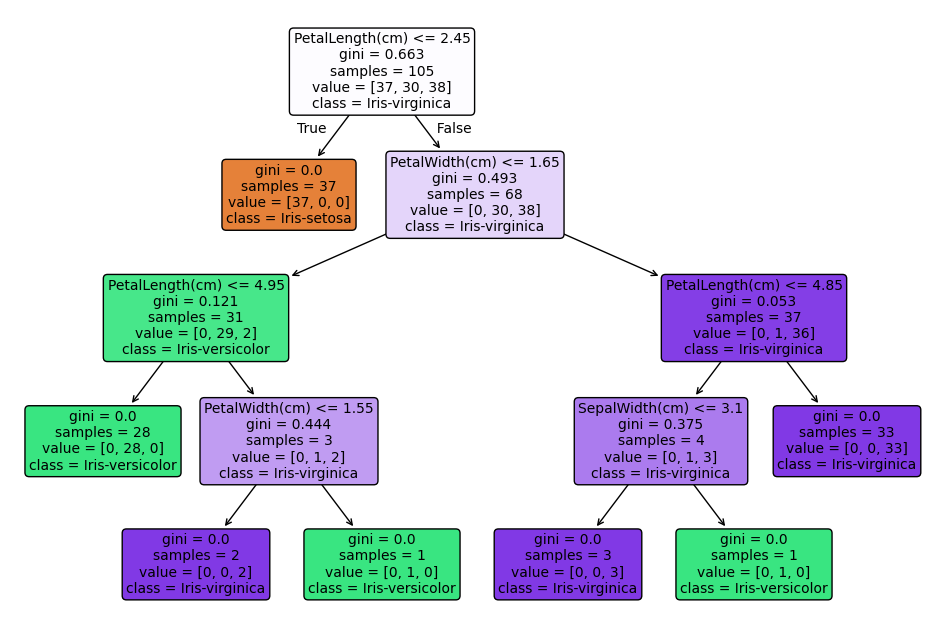

图片已保存到 iris_clf_model_gini.png


In [11]:
'''
生成并显示决策树图
方法一：Graphviz（需系统安装 Graphviz 软件，否则报 ExecutableNotFound）
方法二：matplotlib（无需额外安装，直接用）

参数说明：
- filled=True ：按节点"多数类"填色。颜色越深 = 该节点样本越纯（单一类别占比高）。
  不同类别不同颜色（如 setosa=橙, versicolor=绿, virginica=紫），一眼能看出每个节点"投谁"。
- rounded=True ：节点框圆角，纯美观，不影响信息量。
'''
featureName = ['SepalLength(cm)','SepalWidth(cm)','PetalLength(cm)','PetalWidth(cm)']
className = ['Iris-setosa','Iris-versicolor','Iris-virginica']

# ===== 方法一：Graphviz（需系统安装 Graphviz）=====
# from graphviz import Source
# from sklearn import tree
# graph = Source(tree.export_graphviz(model, out_file=None, feature_names=featureName, class_names=className, filled=True, rounded=True))
# png_clf = graph.pipe(format='png')
# with open('iris_clf_model_gini.png','wb') as f:
#     f.write(png_clf)
# from IPython.display import Image
# Image(png_clf)

# ===== 方法二：matplotlib（无需外部软件）=====
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(12, 8))
tree.plot_tree(model,
               feature_names=featureName,
               class_names=className,
               filled=True,   # 按类别填色，颜色深浅反映纯度
               rounded=True,  # 圆角节点框
               fontsize=10)
plt.savefig('iris_clf_model_gini.png', dpi=150, bbox_inches='tight')
plt.show()
print("图片已保存到 iris_clf_model_gini.png")

In [12]:
'''
模型初步评估

特征重要程度是一个用来降维分析的指标，在我们输出结果里面petal（花瓣）的重要程度占据96%以上，可以说明我们几乎可以单纯通过花瓣就成功识别不同的鸢尾花。

这涉及到降维操作，因为有时候特征量并不仅仅是这4种，在某些企业级的数据科学任务中，维度往往会超过上百上千个，过多的维度会把整个模型的构建周期拉长指数倍，而效益却呈线性甚至减速增长的。

我们会尝试选择算力消耗最少、预测效果最好的方案进行降维。
所以特征重要程度就是一个重要指标。
之后会见到两个名词：SHAP、PCA，就是降维的经典操作。
'''

print("\n特征重要程度为：")
for i in zip(featureName,model.feature_importances_):
    print(i)


print('决策树模型在测试集上的准确率：',model.score(x_test,y_test))
prediction_test = model.predict(x_test)

'''
混淆矩阵能直观表现每种类型的样本之间，哪些样本之间发生了误判，错误识别成了哪些样本

  真实\预测   setosa  versicolor  virginica
  setosa        13        0           0       ← 全对
  versicolor     0       19           1       ← 1个被误判成virginica
  virginica      0        1          11       ← 1个被误判成versicolor
'''
from sklearn import metrics
print('分类报告：\n',metrics.classification_report(y_test,prediction_test))
print('混淆矩阵：\n',metrics.confusion_matrix(y_test,prediction_test))


特征重要程度为：
('SepalLength(cm)', np.float64(0.0))
('SepalWidth(cm)', np.float64(0.021539934354485778))
('PetalLength(cm)', np.float64(0.5595103001691273))
('PetalWidth(cm)', np.float64(0.41894976547638696))
决策树模型在测试集上的准确率： 0.9555555555555556
分类报告：
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.95      0.95      0.95        20
           2       0.92      0.92      0.92        12

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45

混淆矩阵：
 [[13  0  0]
 [ 0 19  1]
 [ 0  1 11]]


In [13]:
'''
===== 补充：课本没讲的决策树核心知识 =====

1. 树是怎么选分裂点的？
   穷举法。对每个特征，把值排序，逐个尝试所有可能的切分点，算哪个切完 Gini/Entropy
   下降最多（信息增益最大）。4特征×100+阈值 → 几百次计算，iris 秒出。
   高维场景（几百特征×几十万行）→ 这就是性能瓶颈，所以才有了 LightGBM 的
   直方图加速（把连续值分桶，只试桶边界，复杂度从 O(n) 降到 O(桶数)）。

2. 为什么不剪枝？
   DecisionTreeClassifier() 默认 max_depth=None → 一直分到每个叶子"纯"（只含一类）。
   iris 数据小、简单，无所谓。换到社交链接数据（几百特征、几十万行），
   不限制深度 → 训练集 AUC 0.99，测试集 0.5，典型的过拟合。
   
   控制过拟合三兄弟（比 criterion 重要十倍）：
   - max_depth          : 树最多几层。越小越泛化，太大过拟合。
   - min_samples_split  : 节点少于 N 个样本就不再分。
   - min_samples_leaf   : 叶子最少要有几个样本。

3. 单棵树 → 集成才是工业界标准。
   一棵树：
   - 容易过拟合
   - 不稳定（换个 random_state，结构可能完全不同）
   - 表达能力有限
   所以才有：
   - 随机森林（Random Forest）：多棵树并行，每棵随机抽样本+随机抽特征，投票决定
   - GBDT（Gradient Boosting Decision Tree）：每棵树学上一棵的残差，串行叠加
   - LightGBM / XGBoost：GBDT 的工程优化版，竞赛和工业界首选
   你社交链接项目用的 LightGBM，本质上就是一群小决策树按顺序加起来。

4. 特征重要度容易被高基数特征"骗"。
   类别多的特征（如 user_id 有几万种取值）天然被树偏爱——因为可切的分裂点多，
   容易被选为分裂特征，但未必真的重要。这就是为什么你的项目中 user_id 不能
   入模的原因之一：它不仅会泄漏标签，还会在特征重要度里虚高，挤掉真正有用的特征。

5. Gini vs Entropy —— 结论：默认 Gini 就对了。
   - Gini = 平方，比 Entropy 的对数快
   - 99% 情况下两者选的分裂点一样
   - LightGBM / XGBoost 默认都是 Gini 分支
   - 类别极不均衡时优先调 class_weight，而不是换 criterion
'''

# ===== 验证：不限制深度 vs 限制深度 =====
from sklearn.tree import DecisionTreeClassifier

model_unlimited = DecisionTreeClassifier(random_state=101)
model_unlimited.fit(x_train, y_train)
print(f"无限制 depth=None → 训练集: {model_unlimited.score(x_train, y_train):.4f},  测试集: {model_unlimited.score(x_test, y_test):.4f}")
print(f"  树的实际深度: {model_unlimited.get_depth()},  叶子数: {model_unlimited.get_n_leaves()}")

model_limited = DecisionTreeClassifier(max_depth=3, random_state=101)
model_limited.fit(x_train, y_train)
print(f"限制 depth=3    → 训练集: {model_limited.score(x_train, y_train):.4f},  测试集: {model_limited.score(x_test, y_test):.4f}")
print(f"  树的实际深度: {model_limited.get_depth()},  叶子数: {model_limited.get_n_leaves()}")

'''
无限制（4 层 / 7 叶子）： 训练集完美 → 它把训练数据背下来了，包括那一点点噪声。结果测试集反而差。

限制 depth=3（3 层 / 5 叶子）： 训练集 98.1% 不如无限制，但测试集 97.8% 反而更高。少了两片叶子，少背了一点噪声，泛化能力反而上去了。

iris 数据太小，差距不明显（45 个样本里差 1 个判断），但趋势已经对了：训练集上的完美往往是测试集上的退步。 换到几十万行的真实数据，深度不限制的树训练集冲 1.0，测试集直接腰斩。
'''

无限制 depth=None → 训练集: 1.0000,  测试集: 0.9556
  树的实际深度: 4,  叶子数: 7
限制 depth=3    → 训练集: 0.9810,  测试集: 0.9778
  树的实际深度: 3,  叶子数: 5

iris 太简单，两者差不多。大数据上无限制模型训练集→1.0，测试集暴跌，肉眼可见的过拟合。
